## 4. EDA Description

### 4.1 Basic Quality Checks

In [58]:
import pandas as pd
import numpy as np

df = pd.read_csv("mushroom_paths.csv")  # or your dedup output
df.head(), df.shape

(                                           file_path  depth file_name  \
 0  Classes/conditionally_edible/horn_of_plenty/8.png      3         8   
 1  Classes/conditionally_edible/horn_of_plenty/9.png      3         9   
 2  Classes/conditionally_edible/horn_of_plenty/14...      3        14   
 3  Classes/conditionally_edible/horn_of_plenty/12...      3        12   
 4  Classes/conditionally_edible/horn_of_plenty/13...      3        13   
 
   file_ext  width  height  num_pixels             phash  aspect_ratio  \
 0      png    512     512      262144  abb9d4a0aae5c4d4           1.0   
 1      png    512     512      262144  a581b66e5c2d6b32           1.0   
 2      png    512     512      262144  d8f40799f31ea870           1.0   
 3      png    512     512      262144  a8a8e950d4af3f58           1.0   
 4      png    512     512      262144  8e86638cdcad5bd0           1.0   
 
                   class         species  
 0  conditionally_edible  horn_of_plenty  
 1  conditionally_edib

In [59]:
# Completeness / quality
print("Missing values per column:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nUnique classes:", df["class"].nunique())
print("Unique species:", df["species"].nunique())
print("File ext counts:\n", df["file_ext"].value_counts().head())

Missing values per column:


file_path       0
depth           0
file_name       0
file_ext        0
width           0
height          0
num_pixels      0
phash           0
aspect_ratio    0
class           0
dtype: int64


Unique classes: 4
Unique species: 570
File ext counts:
 file_ext
jpg     45578
jpeg    45163
png     11959
JPG        11
Name: count, dtype: int64


### 4.2 Class Distribution Plot

In [60]:
import matplotlib.pyplot as plt

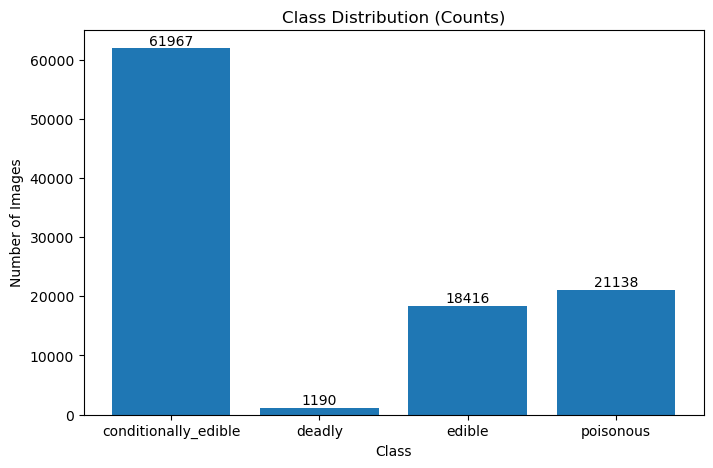

In [61]:
counts = df["class"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values)

plt.title("Class Distribution (Counts)")
plt.xlabel("Class")
plt.ylabel("Number of Images")

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.show()

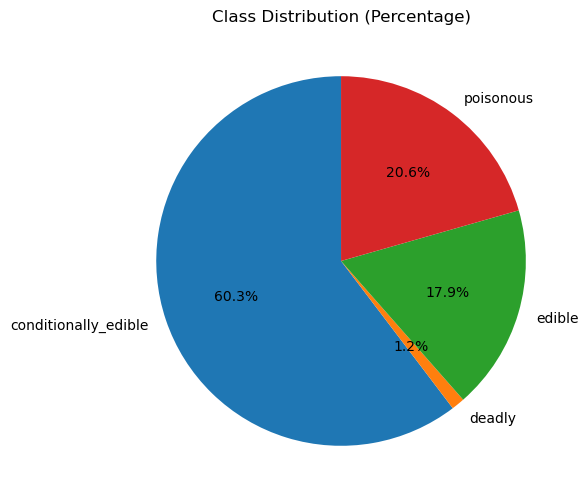

In [62]:
plt.figure(figsize=(6, 6))

plt.pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Class Distribution (Percentage)")
plt.show()

In [63]:
class_dist_table = (
    counts
    .rename("count")
    .to_frame()
)

class_dist_table["percentage"] = (
    class_dist_table["count"] / class_dist_table["count"].sum() * 100
).round(2)

class_dist_table


,count,percentage
class,,
conditionally_edible,61967,60.33
deadly,1190,1.16
edible,18416,17.93
poisonous,21138,20.58


### 4.3 Image Size / Resolution distribution

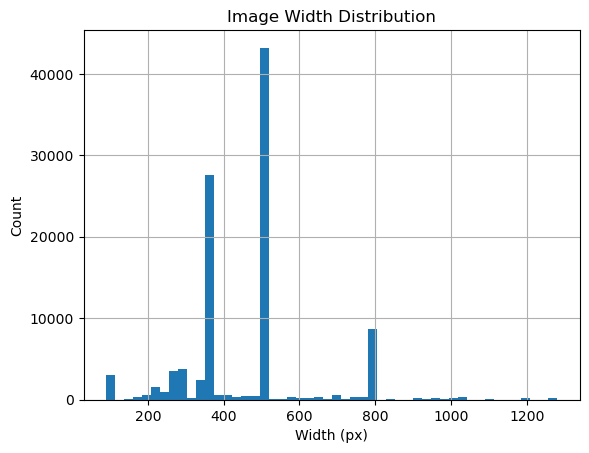

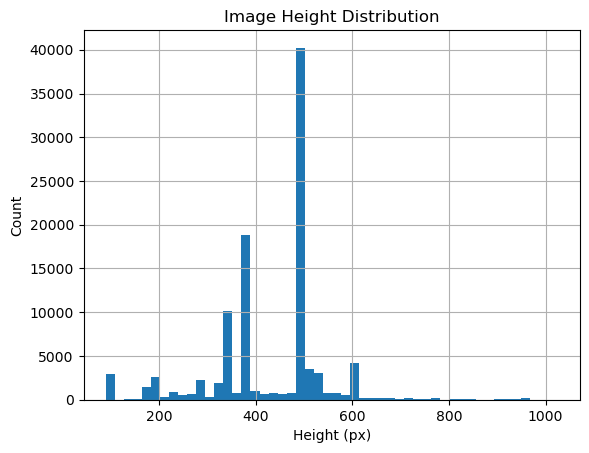

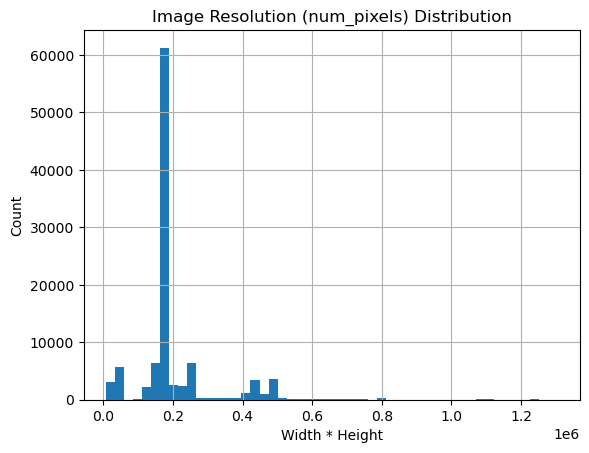

In [64]:
plt.figure()
df["width"].hist(bins=50)
plt.title("Image Width Distribution")
plt.xlabel("Width (px)")
plt.ylabel("Count")
plt.show()

plt.figure()
df["height"].hist(bins=50)
plt.title("Image Height Distribution")
plt.xlabel("Height (px)")
plt.ylabel("Count")
plt.show()

plt.figure()
df["num_pixels"].hist(bins=50)
plt.title("Image Resolution (num_pixels) Distribution")
plt.xlabel("Width * Height")
plt.ylabel("Count")
plt.show()

### 4.4 Aspect Ratio + Scatter (spot outliers)

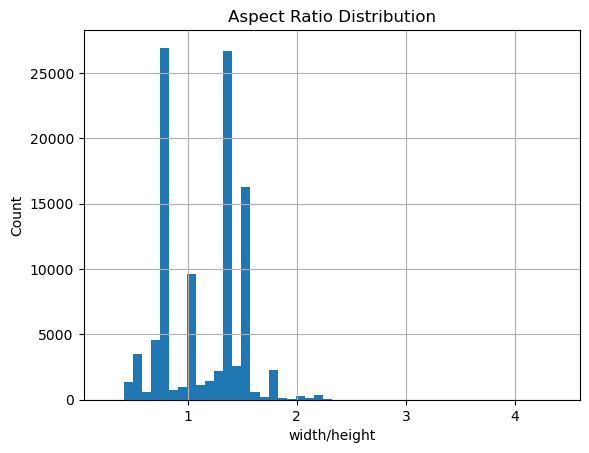

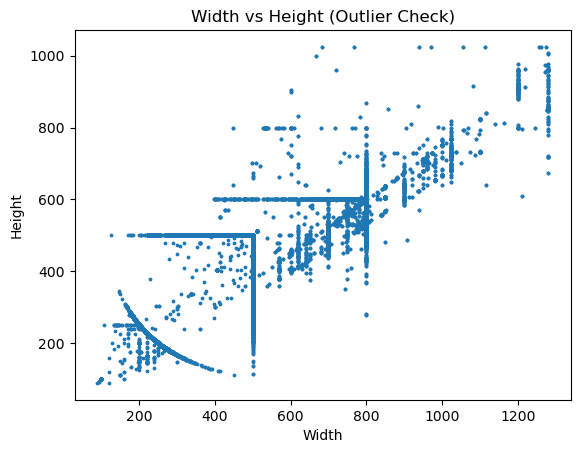

In [65]:
plt.figure()
df["aspect_ratio"].hist(bins=50)
plt.title("Aspect Ratio Distribution")
plt.xlabel("width/height")
plt.ylabel("Count")
plt.show()

# Spot weird sizes/outliers
plt.figure()
plt.scatter(df["width"], df["height"], s=3)
plt.title("Width vs Height (Outlier Check)")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()


### 4.5 Duplicate Check (Exact and Near)

In [66]:
from pathlib import Path

In [67]:
BASE_DIR = Path(".") 

df_raw  = pd.read_csv("mushroom_paths.csv")
df_exact = pd.read_csv("mushroomDedupExact.csv")
df_near  = pd.read_csv("mushroomDedupNear.csv")

print("raw :", df_raw.shape)
print("exact:", df_exact.shape)
print("near :", df_near.shape)


raw : (102711, 11)
exact: (94698, 11)
near : (94631, 11)


**Exact**

Exact duplicate images were identified using perceptual hash (pHash) values. Images sharing the same pHash were considered visually identical. EDA showed that the raw dataset contained multiple images with identical pHash values, indicating exact duplicates. For each group of exact duplicates, only the image with the highest resolution (largest number of pixels) was retained, while lower-resolution copies were removed. After exact deduplication, no repeated pHash values remained in the dataset.

In [68]:
def exact_dup_stats(df):
    vc = df["phash"].astype(str).value_counts()
    dup_hashes = (vc > 1).sum()
    dup_images = vc[vc > 1].sum()
    return dup_hashes, dup_images

rows = []
for name, d in [("raw", df_raw), ("after_exact", df_exact), ("after_near", df_near)]:
    dup_hashes, dup_images = exact_dup_stats(d)
    rows.append({
        "dataset": name,
        "n_rows": len(d),
        "hashes_with_count>1": dup_hashes,
        "images_in_exact_dup_groups": int(dup_images),
        "exact_dup_rate": float(dup_images / len(d))
    })

summary = pd.DataFrame(rows)
summary


,dataset,n_rows,hashes_with_count>1,images_in_exact_dup_groups,exact_dup_rate
0,raw,102711,7623,15636,0.152233
1,after_exact,94698,0,0,0.000000
2,after_near,94631,0,0,0.000000


In [69]:
import matplotlib.pyplot as plt
from PIL import Image

def show_exact_duplicate_group(df, base_dir=BASE_DIR, max_show=6):
    # Count pHash occurrences
    vc = df["phash"].astype(str).value_counts()
    dup_hashes = vc[vc > 1]

    if len(dup_hashes) == 0:
        print("No exact duplicates found.")
        return

    # Take the first duplicate hash as an example
    ph = dup_hashes.index[0]
    group = df[df["phash"].astype(str) == ph].copy()

    # Keep highest-resolution images first
    group = group.sort_values("num_pixels", ascending=False).head(max_show)

    print(f"Example exact-duplicate pHash: {ph}")
    display(group[["file_path", "width", "height", "num_pixels", "class", "species"]])

    plt.figure(figsize=(14, 3))
    for i, (_, row) in enumerate(group.iterrows(), start=1):
        img_path = (base_dir / row["file_path"]).resolve()

        if not img_path.exists():
            raise FileNotFoundError(f"Image not found: {img_path}")

        img = Image.open(img_path).convert("RGB")
        plt.subplot(1, len(group), i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f'{row["width"]}×{row["height"]}')

    plt.show()


Example exact-duplicate pHash: 965a79b4423b7266


,file_path,width,height,num_pixels,class,species
68621,Classes/poisonous/Amanita_roseotincta/Amanita_...,100,100,10000,poisonous,Amanita_roseotincta
73590,Classes/poisonous/Amanita_neoovoidea/Amanita_n...,100,100,10000,poisonous,Amanita_neoovoidea
73618,Classes/poisonous/Amanita_parvipantherina/Aman...,100,100,10000,poisonous,Amanita_parvipantherina
73776,Classes/poisonous/Amanita_ibotengutake/Amanita...,100,100,10000,poisonous,Amanita_ibotengutake
73825,Classes/poisonous/Amanita_smithiana/Amanita_sm...,100,100,10000,poisonous,Amanita_smithiana
74007,Classes/poisonous/Amanita_petalinivolva/Amanit...,100,100,10000,poisonous,Amanita_petalinivolva


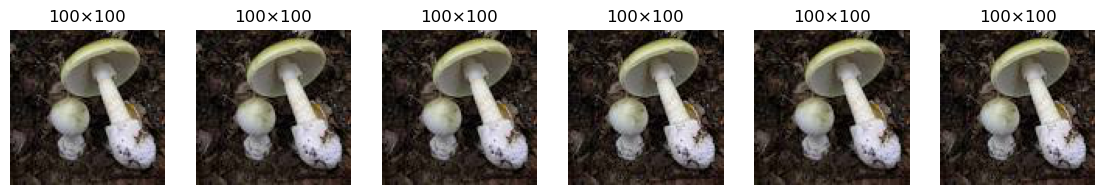

In [70]:
show_exact_duplicate_group(df_raw)


**Near**

Near-duplicate images were identified by computing the Hamming distance between perceptual hash (pHash) values. Images with a Hamming distance below a predefined threshold were considered visually similar but not identical. This method captured cases where images differed slightly due to cropping, resolution, or minor visual variations. As with exact duplicates, the highest-resolution image in each near-duplicate group was retained. After near-duplicate removal, the dataset contained no remaining visually similar duplicates.


In [71]:
from collections import defaultdict

In [72]:
HAMMING_THRESHOLD = 5
PREFIX_LEN = 4

def hamming_hex(h1, h2):
    # robust popcount (works on older Python too)
    x = int(h1, 16) ^ int(h2, 16)
    return bin(x).count("1")

def near_dedup_pairs(df, prefix_len=PREFIX_LEN, thresh=HAMMING_THRESHOLD):
    ph = df["phash"].astype(str).tolist()
    
    buckets = defaultdict(list)
    for idx, h in enumerate(ph):
        buckets[h[:prefix_len]].append(idx)

    # return example near-dup pairs (i, j, distance)
    pairs = []
    for idxs in buckets.values():
        if len(idxs) <= 1:
            continue
        # compare within bucket (still can be big, so we limit example output)
        for a_pos in range(len(idxs)):
            for b_pos in range(a_pos + 1, len(idxs)):
                i, j = idxs[a_pos], idxs[b_pos]
                d = hamming_hex(ph[i], ph[j])
                if d <= thresh and d != 0:  # d==0 are exact duplicates
                    pairs.append((i, j, d))
                    if len(pairs) >= 30:  # limit to keep it fast
                        return pairs
    return pairs

pairs = near_dedup_pairs(df_raw)
print("Found near-duplicate pairs (sample):", len(pairs))
pairs[:5]


Found near-duplicate pairs (sample): 30


[(42230, 42236, 2),
 (87756, 87769, 4),
 (87756, 87775, 4),
 (15525, 72883, 2),
 (62735, 102560, 2)]

In [73]:
def show_near_duplicate_example(df, pairs, base_dir=BASE_DIR):
    if not pairs:
        print("No near-duplicate pairs found (or sampling limit reached).")
        return
    
    i, j, d = pairs[0]
    r1 = df.iloc[i]
    r2 = df.iloc[j]
    print("Example near-duplicate pair")
    print("Hamming distance:", d)
    display(pd.DataFrame([r1, r2])[["file_path", "width", "height", "num_pixels", "class", "species", "phash"]])

    plt.figure(figsize=(8, 4))
    for k, row in enumerate([r1, r2], start=1):
        p = base_dir / row["file_path"]
        img = Image.open(p).convert("RGB")
        plt.subplot(1, 2, k)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f'{row["width"]}x{row["height"]}')
    plt.suptitle(f"Near-duplicate example (Hamming={d})")
    plt.show()


Example near-duplicate pair
Hamming distance: 2


,file_path,width,height,num_pixels,class,species,phash
42230,Classes/conditionally_edible/snakeskin_grisett...,512,512,262144,conditionally_edible,snakeskin_grisette,93cb0de47454ca5b
42236,Classes/conditionally_edible/snakeskin_grisett...,512,512,262144,conditionally_edible,snakeskin_grisette,93cb0de47454ea4b


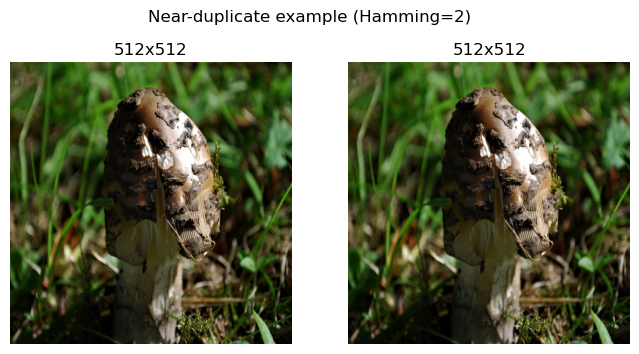

In [74]:
show_near_duplicate_example(df_raw, pairs)

In [75]:
dup_counts = df["phash"].value_counts()
num_dup_hashes = (dup_counts > 1).sum()
num_dup_images = dup_counts[dup_counts > 1].sum()

print("Hashes that appear >1 time:", num_dup_hashes)
print("Images involved in duplicates:", num_dup_images)
print("Duplicate image rate:", num_dup_images / len(df))


Hashes that appear >1 time: 7623
Images involved in duplicates: 15636
Duplicate image rate: 0.15223296433682856


### 4.6 Sample Images per Class (visual sanity check)

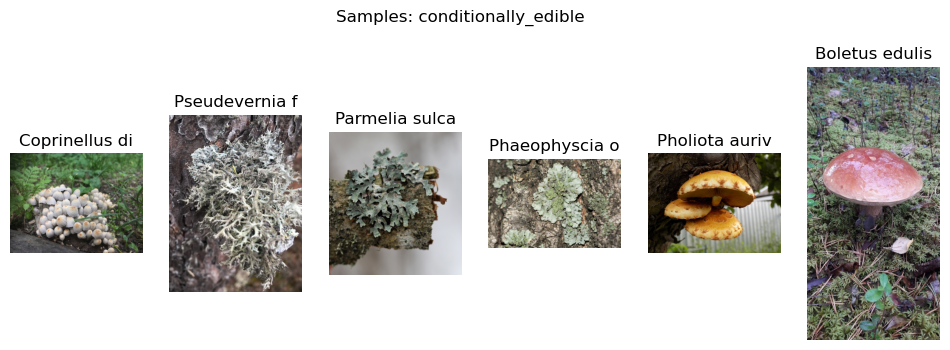

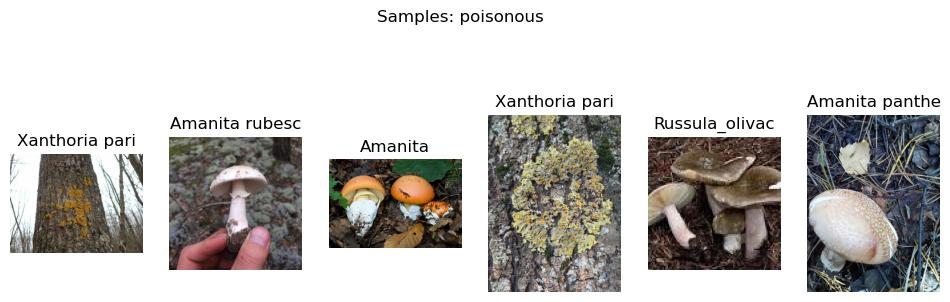

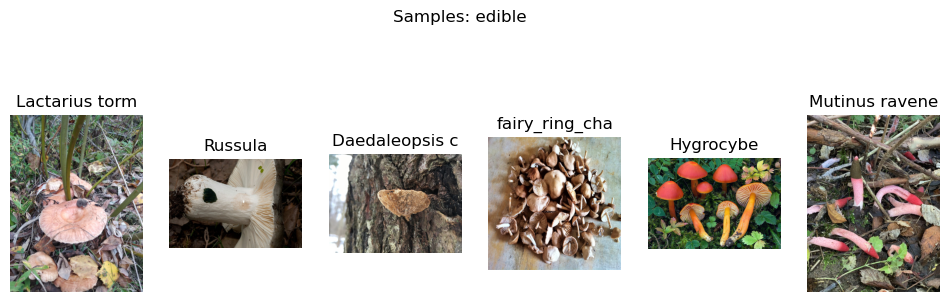

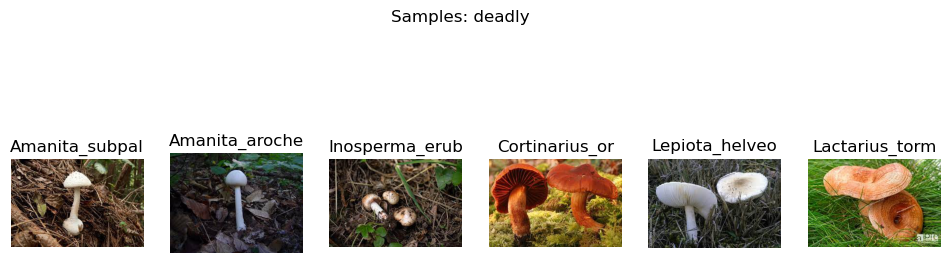

In [76]:
from PIL import Image

def show_samples(df, class_name, n=6):
    sub = df[df["class"] == class_name].sample(n=min(n, len(df[df["class"] == class_name])), random_state=0)
    plt.figure(figsize=(12, 4))
    for i, (_, row) in enumerate(sub.iterrows(), start=1):
        plt.subplot(1, n, i)
        img = Image.open(row["file_path"]).convert("RGB")
        plt.imshow(img)
        plt.axis("off")
        plt.title(row["species"][:14])
    plt.suptitle(f"Samples: {class_name}")
    plt.show()

for c in df["class"].unique():
    show_samples(df, c, n=6)
